In [41]:
from a3em.datasets import arden
import os
from pathlib import Path

In [42]:
prefetch_path = Path(os.getenv('PREFETCH_PATH'))
X_train, X_test, y_train, y_test = arden.load_data(prefetch_path, random_state=123)

prefetching data...
local data found


In [43]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
136,40.039062,184.866385,141.132290,25.390625,288.085938,-20.775877,-18.986094,-360.111026,198.545128,-21.166753,...,0.001834,0.000966,0.000596,0.000304,0.000177,0.000103,0.000049,0.000034,0.000029,0.000026
23,53.710938,175.898063,144.354851,18.554688,265.625000,-3.846918,-4.141425,-232.434715,210.360362,-31.352429,...,0.003189,0.001777,0.001099,0.000793,0.000430,0.000170,0.000066,0.000029,0.000011,0.000008
125,25.390625,136.140110,118.189398,24.414062,123.046875,-1.030607,2.166029,-212.728818,216.290165,-3.622066,...,0.003195,0.001843,0.000936,0.000493,0.000262,0.000135,0.000054,0.000016,0.000004,0.000001
128,33.203125,192.818645,148.374600,24.414062,316.406250,-3.562570,-3.102992,-111.749449,205.814593,-39.727804,...,0.038371,0.021865,0.017778,0.016833,0.007772,0.003446,0.001172,0.000520,0.000115,0.000027
93,25.390625,109.796667,91.474899,24.414062,112.304688,-0.633234,4.921842,-260.057713,218.994703,28.280906,...,0.000767,0.000475,0.000294,0.000146,0.000070,0.000034,0.000016,0.000006,0.000003,0.000002


In [44]:
y_train.head()

136    0
23     0
125    1
128    0
93     1
Name: label, dtype: int64

In [45]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [46]:
import pandas as pd

In [47]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [48]:
labels_aggregate['label'].value_counts()

label
1    184
0    179
Name: count, dtype: int64

In [49]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [50]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,40.039062,184.866385,141.132290,25.390625,288.085938,-20.775877,-18.986094,-360.111026,198.545128,-21.166753,...,0.000966,0.000596,0.000304,0.000177,0.000103,0.000049,0.000034,0.000029,0.000026,0
1,53.710938,175.898063,144.354851,18.554688,265.625000,-3.846918,-4.141425,-232.434715,210.360362,-31.352429,...,0.001777,0.001099,0.000793,0.000430,0.000170,0.000066,0.000029,0.000011,0.000008,0
2,25.390625,136.140110,118.189398,24.414062,123.046875,-1.030607,2.166029,-212.728818,216.290165,-3.622066,...,0.001843,0.000936,0.000493,0.000262,0.000135,0.000054,0.000016,0.000004,0.000001,1
3,33.203125,192.818645,148.374600,24.414062,316.406250,-3.562570,-3.102992,-111.749449,205.814593,-39.727804,...,0.021865,0.017778,0.016833,0.007772,0.003446,0.001172,0.000520,0.000115,0.000027,0
4,25.390625,109.796667,91.474899,24.414062,112.304688,-0.633234,4.921842,-260.057713,218.994703,28.280906,...,0.000475,0.000294,0.000146,0.000070,0.000034,0.000016,0.000006,0.000003,0.000002,1


### Compute Summary Statistics

In [51]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,36.328125,24.884523,10.653574,2.984471
centroid,171.584968,118.637574,23.251801,10.785884
bandwidth,138.055502,99.210284,12.507148,9.927211
freq_5,22.974537,23.722628,5.908760,2.082273
freq_95,257.060185,121.179288,59.215373,6.338231
hnr,-7.581268,0.613023,6.690256,3.425315
hnr_low,-6.500990,6.152591,7.360936,3.659909
mfcc_1,-207.160295,-263.732546,87.724241,31.554324
mfcc_2,209.028599,218.258747,14.466536,7.285560
mfcc_3,-24.067271,23.574862,20.735717,14.327257


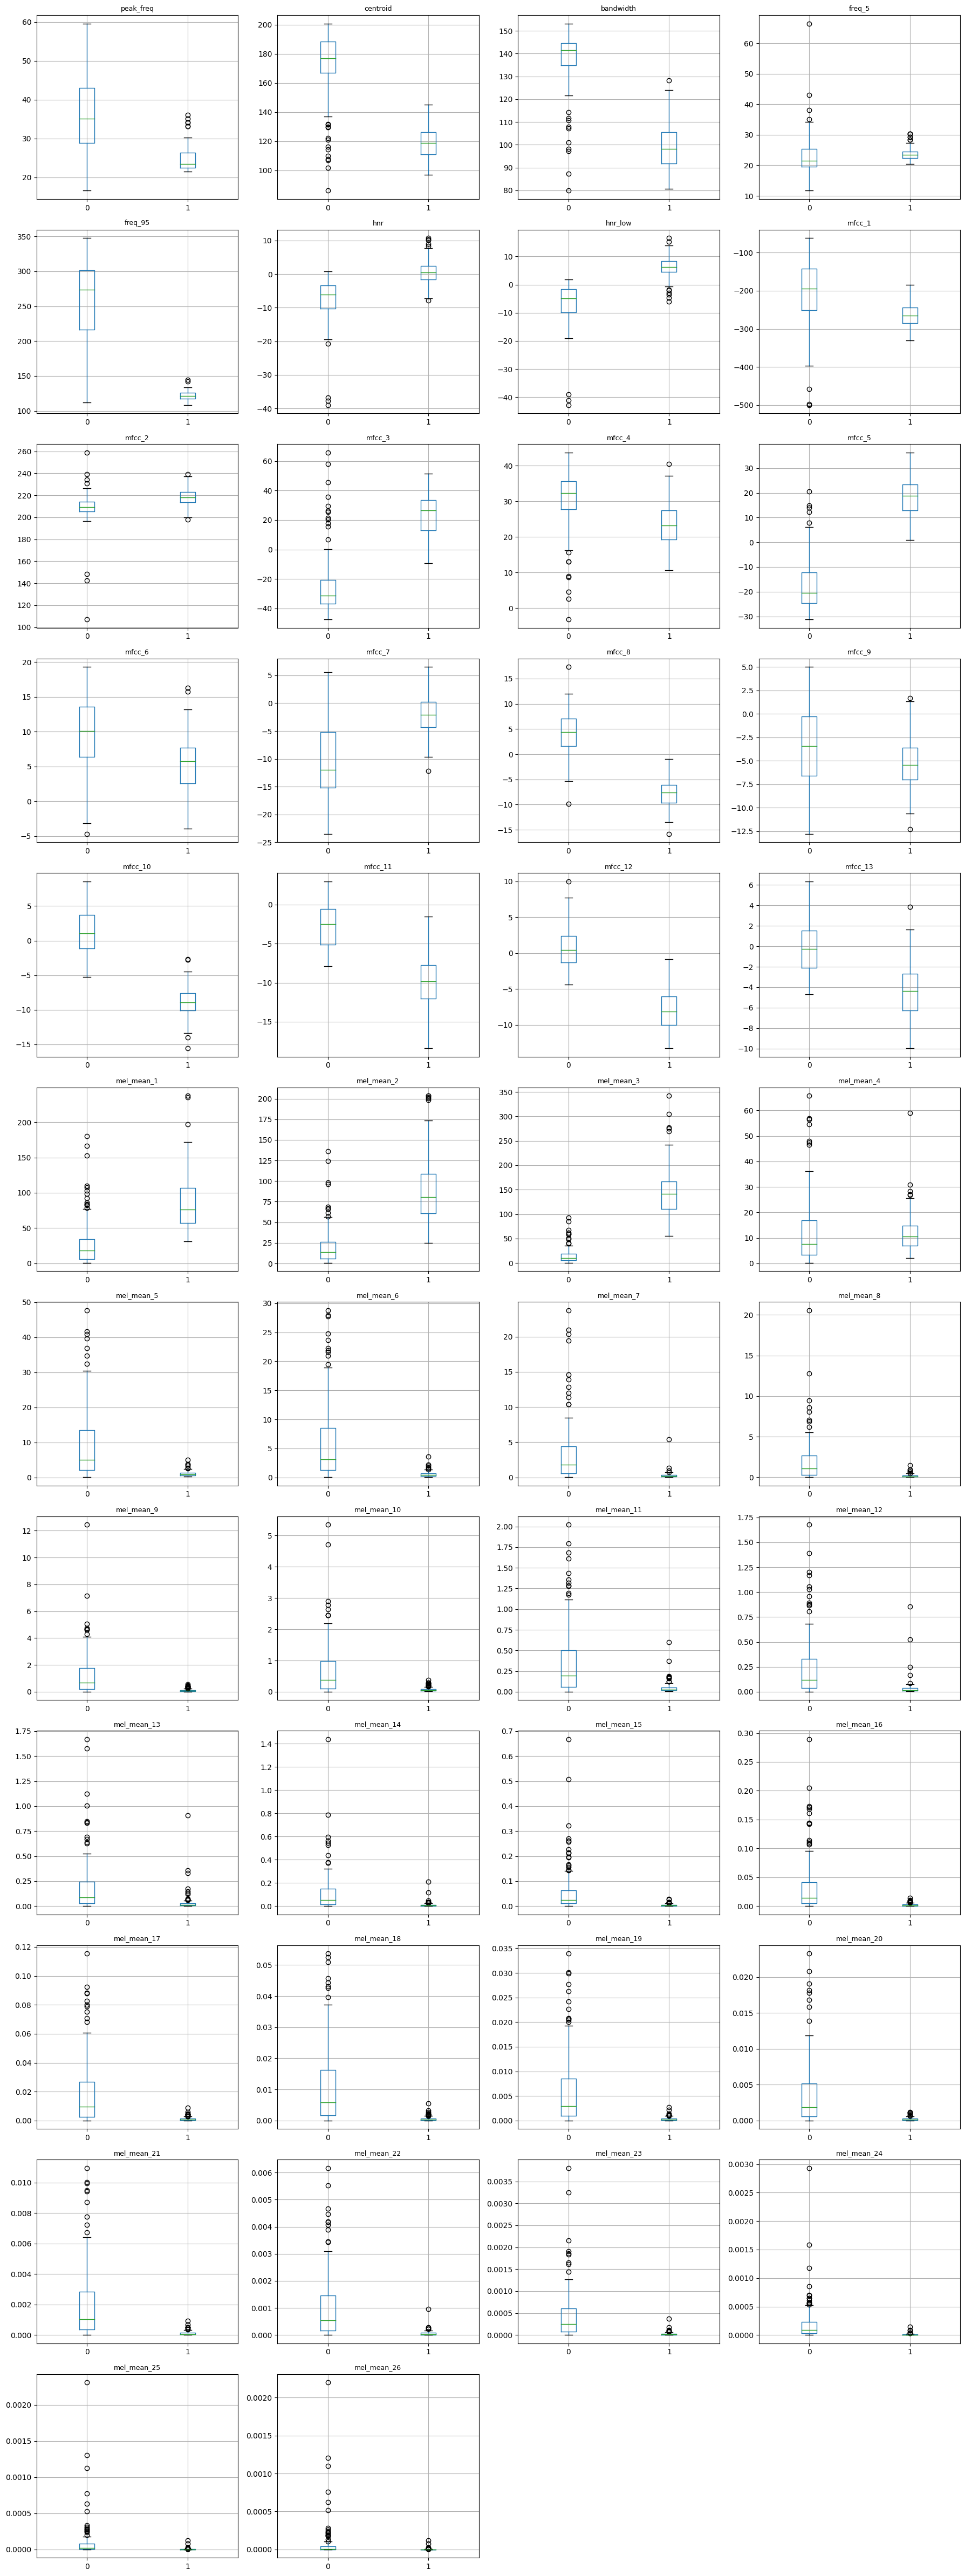

In [52]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [53]:
from scipy.stats import mannwhitneyu

In [54]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [55]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,36.0,9.158807e-46
16,mfcc_10,18456.0,9.783542e-46
18,mfcc_12,18345.0,1.107427e-44
14,mfcc_8,18315.0,2.123043e-44
11,mfcc_5,255.0,1.070345e-43
4,freq_95,18232.5,1.198918e-43
6,hnr_low,399.0,2.302801e-42
2,bandwidth,17923.0,8.614533e-41
17,mfcc_11,17804.0,9.985836e-40
21,mel_mean_2,843.0,2.175196e-38


In [56]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,36.0,9.158807e-46,True
16,mfcc_10,18456.0,9.783542e-46,True
18,mfcc_12,18345.0,1.107427e-44,True
14,mfcc_8,18315.0,2.123043e-44,True
11,mfcc_5,255.0,1.070345e-43,True
4,freq_95,18232.5,1.198918e-43,True
6,hnr_low,399.0,2.302801e-42,True
2,bandwidth,17923.0,8.614533e-41,True
17,mfcc_11,17804.0,9.985836e-40,True
21,mel_mean_2,843.0,2.175196e-38,True


In [57]:
results["Significant"].value_counts()

Significant
True    46
Name: count, dtype: int64

In [58]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [59]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [60]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(272, 46)
(91, 46)
label
1    137
0    135
Name: count, dtype: int64
label
1    47
0    44
Name: count, dtype: int64


In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [63]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[44  0]
 [ 0 47]]


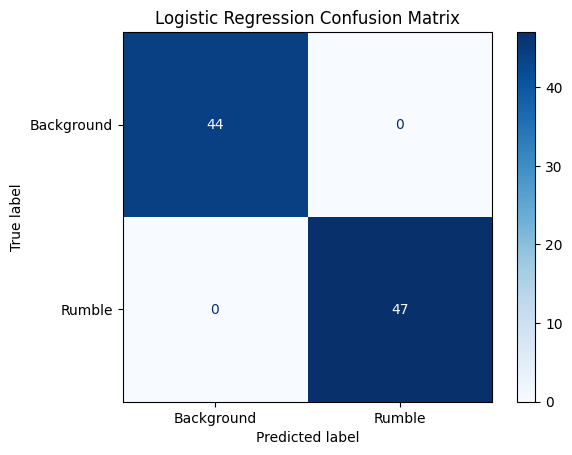

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        47

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



In [67]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 1.000


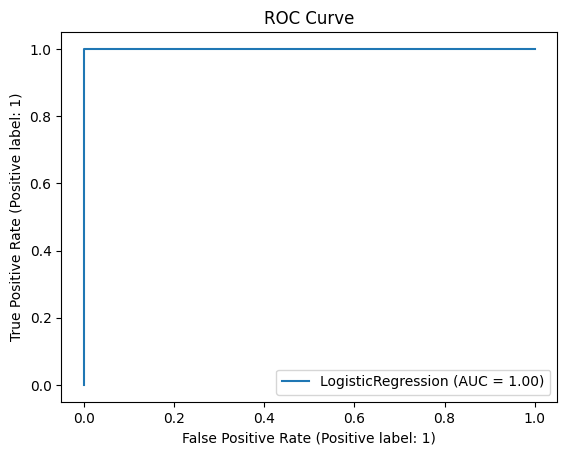

In [68]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [69]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,0.903856,0.903856
0,peak_freq,-0.763023,0.763023
22,mel_mean_3,0.723478,0.723478
5,hnr,0.672558,0.672558
17,mfcc_11,-0.657403,0.657403
14,mfcc_8,-0.643861,0.643861
16,mfcc_10,-0.612051,0.612051
18,mfcc_12,-0.538662,0.538662
4,freq_95,-0.453414,0.453414
11,mfcc_5,0.399340,0.399340


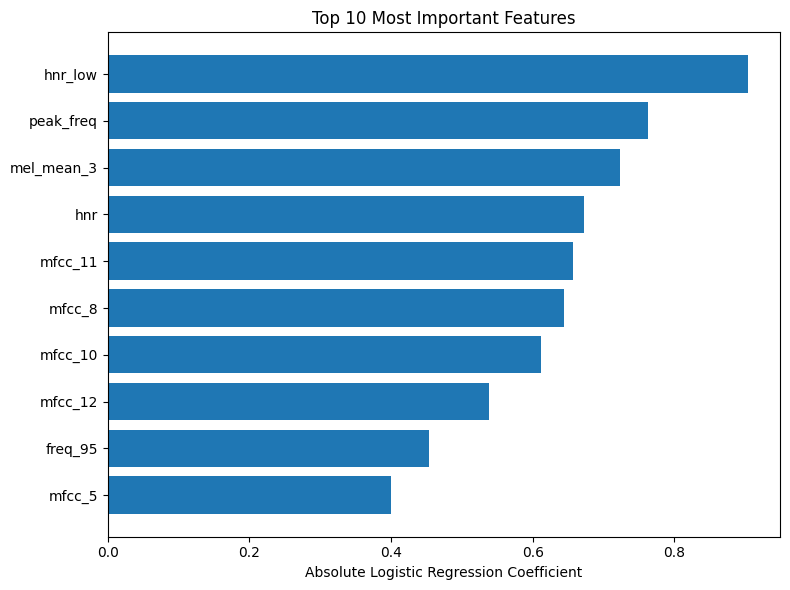

In [70]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [71]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,0.903856,0.903856,399.0,2.302801e-42,True,1.513269e-41,True
1,peak_freq,-0.763023,0.763023,15776.5,6.081498e-24,True,8.742153e-24,True
2,mel_mean_3,0.723478,0.723478,36.0,9.158807e-46,True,2.250215e-44,True
3,hnr,0.672558,0.672558,1530.0,1.229537e-32,True,4.350669e-32,True
4,mfcc_11,-0.657403,0.657403,17804.0,9.985836e-40,True,5.103872e-39,True
5,mfcc_8,-0.643861,0.643861,18315.0,2.123043e-44,True,2.441499e-43,True
6,mfcc_10,-0.612051,0.612051,18456.0,9.783542e-46,True,2.250215e-44,True
7,mfcc_12,-0.538662,0.538662,18345.0,1.107427e-44,True,1.698055e-43,True
8,freq_95,-0.453414,0.453414,18232.5,1.198918e-43,True,9.191708e-43,True
9,mfcc_5,0.399340,0.399340,255.0,1.070345e-43,True,9.191708e-43,True


### Cross Validation with Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [74]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [75]:
rf_pred = rf_model.predict(X_test)

In [76]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.98      0.99        47

    accuracy                           0.99        91
   macro avg       0.99      0.99      0.99        91
weighted avg       0.99      0.99      0.99        91



### RandomForest Feature Importance

In [77]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
22,mel_mean_3,0.129207
4,freq_95,0.116674
2,bandwidth,0.103837
6,hnr_low,0.096133
16,mfcc_10,0.087756
11,mfcc_5,0.084497
14,mfcc_8,0.069674
18,mfcc_12,0.063948
9,mfcc_3,0.036431
1,centroid,0.030603


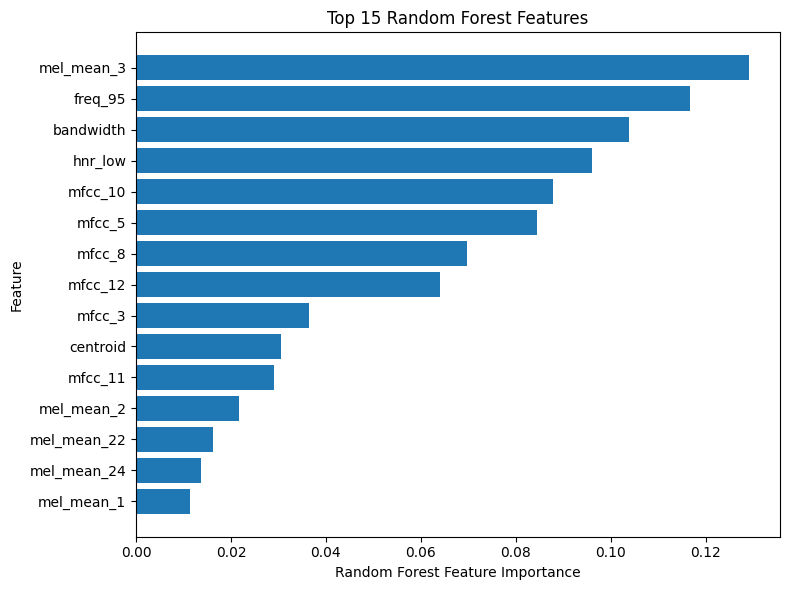

In [78]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [79]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
0,mel_mean_3,9.158807e-46,0.723478,0.129207,1,3,1,1.666667
6,hnr_low,2.302801e-42,0.903856,0.096133,7,1,4,4.000000
1,mfcc_10,9.783542e-46,-0.612051,0.087756,2,7,5,4.666667
3,mfcc_8,2.123043e-44,-0.643861,0.069674,4,6,7,5.666667
5,freq_95,1.198918e-43,-0.453414,0.116674,6,9,2,5.666667
2,mfcc_12,1.107427e-44,-0.538662,0.063948,3,8,8,6.333333
4,mfcc_5,1.070345e-43,0.399340,0.084497,5,10,6,7.000000
8,mfcc_11,9.985836e-40,-0.657403,0.028977,9,5,11,8.333333
7,bandwidth,8.614533e-41,-0.173266,0.103837,8,16,3,9.000000
12,hnr,1.229537e-32,0.672558,0.009804,13,4,18,11.666667
